### ШАГ 1 - Небольшой анализ полученных данных


In [1]:
import pandas as pd
import numpy as np

path = '/kaggle/input/datasets/nikolasking/data-ease/prepared_train_data.csv'
data = pd.read_csv(path)

print(f"Размер данных: {data.shape}")
print(f"Колонки: {data.columns.tolist()}")
print("-" * 50)
print("\nТипы данных:")
print(data.dtypes)

Размер данных: (856700, 15)
Колонки: ['userId', 'movieId', 'score', 'title', 'genres', 'popularity', 'age', 'rating', 'runtimeMinutes', 'num_translations', 'main_region', 'is_multiregional', 'actors_list', 'director_name', 'cluster']
--------------------------------------------------

Типы данных:
userId                int64
movieId               int64
score               float64
title                object
genres               object
popularity          float64
age                 float64
rating              float64
runtimeMinutes      float64
num_translations    float64
main_region          object
is_multiregional     object
actors_list          object
director_name        object
cluster             float64
dtype: object


In [2]:
data.head()

,userId,movieId,score,title,genres,popularity,age,rating,runtimeMinutes,num_translations,main_region,is_multiregional,actors_list,director_name,cluster
0,28,70,0.199366,From Dusk Till Dawn,"['Action', 'Comedy', 'Horror', 'Thriller']",0.000446,29.0,3.202508,108.0,51.0,CA,True,"['Harvey Keitel', 'George Clooney', 'Juliette ...",Robert Rodriguez,23.0
1,28,2424,0.190685,You've Got Mail,"['Comedy', 'Romance']",0.000398,27.0,3.053162,119.0,58.0,CA,True,"['Tom Hanks', 'Meg Ryan', 'Greg Kinnear', 'Par...",NaN,23.0
2,28,31878,0.183384,Kung Fu Hustle (Gong fu),"['Action', 'Comedy']",0.000261,21.0,3.561326,99.0,55.0,IN,True,['Stephen Chow'],Stephen Chow,3.0
3,28,37729,0.169491,Corpse Bride,"['Animation', 'Comedy', 'Fantasy', 'Musical', ...",0.000436,20.0,3.334100,77.0,60.0,CA,True,"['Johnny Depp', 'Helena Bonham Carter', 'Emily...",Tim Burton,23.0
4,28,5014,0.167917,I Am Sam,['Drama'],0.000189,24.0,3.365230,132.0,40.0,ES,True,"['Sean Penn', 'Michelle Pfeiffer', 'Dakota Fan...",NaN,23.0


In [3]:
nan_analysis = pd.DataFrame({
    'count_nan': data.isnull().sum(),
    'pct_nan': (data.isnull().sum() / len(data) * 100).round(2)
}).sort_values('pct_nan', ascending=False)

print("Пропущенные значения:")
print(nan_analysis[nan_analysis.count_nan > 0])
print(f"\nВсего строк: {len(data)}")
print(f"Колонок с NaN: {(nan_analysis.count_nan > 0).sum()}")

Пропущенные значения:
                  count_nan  pct_nan
director_name        475103    55.46
is_multiregional      24377     2.85
main_region           24377     2.85
num_translations      24377     2.85
actors_list           24377     2.85
runtimeMinutes        24377     2.85
age                     483     0.06
cluster                  36     0.00

Всего строк: 856700
Колонок с NaN: 8


In [4]:
print(f"Уникальных пользователей: {data['userId'].nunique()}")
print(f"Уникальных фильмов: {data['movieId'].nunique()}")
print(f"Строк на пользователя (среднее): {len(data) / data['userId'].nunique():.1f}")

# Проверяем дубликаты (пара user-movie должна быть уникальной)
dupes = data.duplicated(subset=['userId', 'movieId']).sum()
print(f"\nДубликатов (userId, movieId): {dupes}")

Уникальных пользователей: 8567
Уникальных фильмов: 5333
Строк на пользователя (среднее): 100.0

Дубликатов (userId, movieId): 0


In [5]:
# Смотрим на реальный формат
print("Пример genres:", data['genres'].iloc[0])
print("Тип genres:", type(data['genres'].iloc[0]))
print()
print("Пример actors_list:", data['actors_list'].iloc[0])
print()
print("Пример director_name:", data['director_name'].iloc[:5].tolist())
print("NaN в director_name:", data['director_name'].isnull().sum())

Пример genres: ['Action', 'Comedy', 'Horror', 'Thriller']
Тип genres: <class 'str'>

Пример actors_list: ['Harvey Keitel', 'George Clooney', 'Juliette Lewis', 'Quentin Tarantino', 'Salma Hayek', 'Cheech Marin', 'Danny Trejo', 'Fred Williamson']

Пример director_name: ['Robert Rodriguez', nan, 'Stephen Chow', 'Tim Burton', nan]
NaN в director_name: 475103


### ШАГ 2 - Загрузка датасета для создания label и обучение моделей на основе имеющихся данных

In [6]:
df = pd.read_csv('/kaggle/input/datasets/nikolasking/user-item-data-recsys/ratings.csv', 
                   usecols=['userId', 'movieId', 'rating', 'timestamp'])

In [7]:
display(df.dtypes)
display(df.head())

userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [8]:
df.rating.unique()

array([4. , 1. , 2. , 5. , 3. , 3.5, 0.5, 4.5, 2.5, 1.5])

In [9]:
df.rating = df.rating.astype(int)

In [10]:
# Разделим на трейн и тест по 01.01.2018
train_df = df.loc[(df.timestamp < 1514764800)].copy()
test_df = df.loc[(df.timestamp >= 1514764800)].copy()

In [11]:
train_users = train_df.userId.unique()
test_users = test_df.userId.unique()

# Возьмем только тех людей, которые попали и в трейн, и в тест
all_included = np.intersect1d(train_users, test_users)

n_users = all_included.shape[0]

# В трейне и тесте выделим только тех, кто есть и там, и там
train_df = train_df.loc[train_df.userId.isin(all_included)].copy()
test_df = test_df.loc[test_df.userId.isin(all_included)].copy()

# Сгруппируем все интеракции по пользователям
train_grouped = train_df.groupby('userId').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.movieId, 
                                                 x.rating), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('userId').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.movieId,
                                                         x.rating), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

/tmp/ipykernel_57/506008888.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_grouped = train_df.groupby('userId').apply(
/tmp/ipykernel_57/506008888.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_grouped = test_df.groupby('userId').apply(


,userId,train_interactions
0,28,"[(8666, 0), (54, 1), (75, 1), (160, 1), (174, ..."
1,35,"[(1247, 2), (1590, 2), (1917, 2), (6365, 2), (..."
2,100,"[(49274, 1), (60069, 1), (34, 2), (1127, 2), (..."
3,111,"[(104, 2), (288, 2), (356, 2), (2424, 2), (316..."
4,140,"[(94959, 2), (168254, 2), (6870, 3), (56587, 3..."


In [12]:
joined = train_grouped.merge(test_grouped)
joined

,userId,train_interactions,test_interactions
0,28,"[(8666, 0), (54, 1), (75, 1), (160, 1), (174, ...","[(4125, 0), (4138, 0), (261759, 1), (5679, 2),..."
1,35,"[(1247, 2), (1590, 2), (1917, 2), (6365, 2), (...","[(2513, 2), (5218, 2), (5618, 2), (7115, 2), (..."
2,100,"[(49274, 1), (60069, 1), (34, 2), (1127, 2), (...","[(8533, 1), (222477, 1), (608, 2), (1183, 2), ..."
3,111,"[(104, 2), (288, 2), (356, 2), (2424, 2), (316...","[(168330, 3), (158238, 4)]"
4,140,"[(94959, 2), (168254, 2), (6870, 3), (56587, 3...","[(160954, 3), (176101, 5), (177593, 5), (17776..."
...,...,...,...
8562,200898,"[(4306, 3), (115713, 3), (122904, 3), (152081,...","[(2662, 2), (6534, 3), (78469, 3), (85414, 3),..."
8563,200915,"[(88267, 0), (18, 1), (592, 1), (1676, 1), (21...","[(60069, 5)]"
8564,200920,"[(159721, 0), (56949, 1), (63992, 1), (72407, ...","[(179819, 3), (122906, 4), (122912, 5)]"
8565,200930,"[(2706, 0), (4718, 0), (122904, 0), (171729, 0...","[(112556, 0), (140880, 0), (176149, 0), (92259..."


Проверяем базовую статистику joined:

In [13]:
print(f"Пользователей в joined: {len(joined)}")
print(f"Совпадает с n_users: {len(joined) == n_users}")
print()

# Длина train_interactions у каждого пользователя
train_lengths = joined['train_interactions'].apply(len)
test_lengths = joined['test_interactions'].apply(len)

print("Длина train_interactions:")
print(train_lengths.describe())
print()
print("Длина test_interactions:")
print(test_lengths.describe())

Пользователей в joined: 8567
Совпадает с n_users: True

Длина train_interactions:
count     8567.000000
mean       428.277343
std        570.826992
min          1.000000
25%         96.000000
50%        249.000000
75%        555.000000
max      19042.000000
Name: train_interactions, dtype: float64

Длина test_interactions:
count     8567.000000
mean       136.651453
std        305.066396
min          1.000000
25%         14.000000
50%         46.000000
75%        144.000000
max      14290.000000
Name: test_interactions, dtype: float64


Сверяем userId из joined с userId из prepared_train_data:

In [14]:
joined_users = set(joined['userId'].unique())
data_users = set(data['userId'].unique())

print(f"Пользователей в joined:              {len(joined_users)}")
print(f"Пользователей в prepared_train_data: {len(data_users)}")
print(f"Пересечение:                         {len(joined_users & data_users)}")
print(f"Есть в joined, нет в data:           {len(joined_users - data_users)}")
print(f"Есть в data, нет в joined:           {len(data_users - joined_users)}")

Пользователей в joined:              8567
Пользователей в prepared_train_data: 8567
Пересечение:                         8567
Есть в joined, нет в data:           0
Есть в data, нет в joined:           0


# NeuMF

In [16]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from collections import deque
from tqdm.notebook import tqdm

In [17]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


In [18]:
# Фитим энкодеры ТОЛЬКО на train (как в семинаре)
user_encoder = LabelEncoder().fit(train_df["userId"].values)
item_encoder = LabelEncoder().fit(train_df["movieId"].values)

In [19]:
n_users = len(user_encoder.classes_)
n_items = len(item_encoder.classes_)
print(f"Users: {n_users}, Items: {n_items}")

Users: 8567, Items: 42610


In [20]:
# Кодируем train
train_encoded_users = torch.tensor(
    user_encoder.transform(train_df["userId"].values), dtype=torch.long
)
train_encoded_items = torch.tensor(
    item_encoder.transform(train_df["movieId"].values), dtype=torch.long
)

In [21]:
# Словарь: закодированный user → множество закодированных items (для neg sampling)
encoded_uid_col = user_encoder.transform(train_df["userId"].values)
encoded_iid_col = item_encoder.transform(train_df["movieId"].values)

In [22]:
user_seen_items: dict[int, set] = {}
for u, i in zip(encoded_uid_col, encoded_iid_col):
    user_seen_items.setdefault(int(u), set()).add(int(i))

all_items = set(range(n_items))

In [23]:
print("Предпосчёт unseen items...")
user_unseen_items: dict[int, np.ndarray] = {}
for enc_uid in tqdm(range(n_users)):
    seen = user_seen_items.get(enc_uid, set())
    unseen = np.array(list(all_items - seen), dtype=np.int32)
    user_unseen_items[enc_uid] = unseen
print("Готово!")

Предпосчёт unseen items...


  0%|          | 0/8567 [00:00<?, ?it/s]

Готово!


In [24]:
class NCF(nn.Module):
    def __init__(self, n_users, m_items, n_factors, hidden_dim):
        super().__init__()
        self.m_items = m_items

        self.user_emb_gmf = nn.Embedding(n_users, n_factors)
        self.item_emb_gmf = nn.Embedding(m_items, n_factors)
        self.user_emb_mlp = nn.Embedding(n_users, n_factors)
        self.item_emb_mlp = nn.Embedding(m_items, n_factors)

        self.mlp = nn.Sequential(
            nn.Linear(2 * n_factors, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
        )
        self.out = nn.Linear(n_factors + hidden_dim // 2, 1)
        self._init_weights()

    def _init_weights(self):
        for emb in [self.user_emb_gmf, self.item_emb_gmf,
                    self.user_emb_mlp, self.item_emb_mlp]:
            nn.init.normal_(emb.weight, std=0.01)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
        nn.init.xavier_uniform_(self.out.weight)

    def forward(self, item: torch.Tensor, user: torch.Tensor):
        u_gmf = self.user_emb_gmf(user)
        i_gmf = self.item_emb_gmf(item)
        gmf   = u_gmf * i_gmf

        u_mlp = self.user_emb_mlp(user)
        i_mlp = self.item_emb_mlp(item)
        mlp_out = self.mlp(torch.cat([u_mlp, i_mlp], dim=-1))

        x = torch.cat([gmf, mlp_out], dim=-1)
        return self.out(x).squeeze(-1)


ncf_model = NCF(
    n_users=n_users, m_items=n_items,
    n_factors=32, hidden_dim=128
).to(DEVICE)
print(ncf_model)

NCF(
  (user_emb_gmf): Embedding(8567, 32)
  (item_emb_gmf): Embedding(42610, 32)
  (user_emb_mlp): Embedding(8567, 32)
  (item_emb_mlp): Embedding(42610, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (out): Linear(in_features=96, out_features=1, bias=True)
)


In [25]:
BATCH_SIZE = 2048
N_EPOCHS   = 3
LR         = 1e-3

optimizer = torch.optim.Adam(ncf_model.parameters(), lr=LR)
loss_fn   = nn.BCEWithLogitsLoss()

In [26]:
N = len(train_encoded_users)

for epoch in range(N_EPOCHS):
    ncf_model.train()
    perm = torch.randperm(N)
    shuffled_users = train_encoded_users[perm]
    shuffled_items = train_encoded_items[perm]

    loss_window = deque(maxlen=200)
    pbar = tqdm(range(0, N, BATCH_SIZE),
                desc=f"Epoch {epoch+1}/{N_EPOCHS}")

    for start in pbar:
        users_batch = shuffled_users[start:start + BATCH_SIZE].to(DEVICE)
        items_batch = shuffled_items[start:start + BATCH_SIZE].to(DEVICE)
        B = len(users_batch)

        # БЫСТРЫЙ neg sampling — numpy векторизованно
        user_list = users_batch.cpu().numpy()
        neg_items = np.array([
            user_unseen_items[u][np.random.randint(len(user_unseen_items[u]))]
            for u in user_list
        ], dtype=np.int64)
        neg_items_t = torch.from_numpy(neg_items).to(DEVICE)

        optimizer.zero_grad()
        pos_pred = ncf_model(items_batch, users_batch)
        neg_pred = ncf_model(neg_items_t, users_batch)

        loss = (
            loss_fn(pos_pred, torch.ones(B, device=DEVICE)) +
            loss_fn(neg_pred, torch.zeros(B, device=DEVICE))
        )
        loss.backward()
        optimizer.step()

        loss_window.append(loss.item())
        pbar.set_postfix(loss=f"{np.mean(loss_window):.4f}")

    print(f"Epoch {epoch+1} done | avg loss: {np.mean(loss_window):.4f}")

Epoch 1/3:   0%|          | 0/1792 [00:00<?, ?it/s]

Epoch 1 done | avg loss: 0.4521


Epoch 2/3:   0%|          | 0/1792 [00:00<?, ?it/s]

Epoch 2 done | avg loss: 0.4033


Epoch 3/3:   0%|          | 0/1792 [00:00<?, ?it/s]

Epoch 3 done | avg loss: 0.3695


In [15]:
# метрики
def dcg(scores):
    return np.sum((2**scores - 1) / np.log2(np.arange(len(scores)) + 2))

def ndcg_metric(gt_items, predicted, k=10):
    predicted  = predicted[:k]
    relevance  = np.array([1 if x in gt_items else 0 for x in predicted])
    rank_dcg   = dcg(relevance)
    ideal_dcg  = dcg(np.sort(relevance)[::-1])
    return rank_dcg / ideal_dcg if ideal_dcg > 0 else 0

def precision_at_k(gt_items, predicted, k=10):
    return len(set(predicted[:k]) & set(gt_items)) / k

def recall_at_k(gt_items, predicted, k=50):
    if len(gt_items) == 0:
        return 0.0
    return len(set(predicted[:k]) & set(gt_items)) / len(gt_items)

def evaluate(df, score_col, k_ndcg=10, k_prec=10, k_rec=10):
    ndcg_list, prec_list, rec_list = [], [], []
    for user_id, group in df.groupby("userId"):
        true_items = set(group[group["label"] == 1]["movieId"])
        if len(true_items) == 0:
            continue
        recs = group.sort_values(score_col, ascending=False)["movieId"].tolist()
        ndcg_list.append(ndcg_metric(true_items, recs, k=k_ndcg))
        prec_list.append(precision_at_k(true_items, recs, k=k_prec))
        rec_list.append(recall_at_k(true_items, recs, k=k_rec))
    return np.mean(ndcg_list), np.mean(prec_list), np.mean(rec_list)

In [28]:
# ИНФЕРЕНС - строим test_eval_df для evaluate()

In [29]:
# ============================================================
# 5. ИНФЕРЕНС + МЕТРИКИ БЕЗ НАКОПЛЕНИЯ ВСЕГО DataFrame
# ============================================================

ncf_model.eval()

ndcg_list, prec_list, rec_list = [], [], []

# Ground truth из joined (там уже есть test_interactions)
test_gt = {
    row.userId: set(t[0] for t in row.test_interactions)
    for row in joined.itertuples()
}

# Только юзеры которых знает энкодер
test_users_known = [
    u for u in joined["userId"].values
    if u in set(user_encoder.classes_)
]

K_NDCG, K_PREC, K_REC = 10, 15, 50
# Размер чанка — сколько юзеров обрабатываем за раз
CHUNK_SIZE = 100

with torch.no_grad():
    for start in tqdm(range(0, len(test_users_known), CHUNK_SIZE),
                      desc="Inference"):
        chunk_users = test_users_known[start:start + CHUNK_SIZE]
        
        for orig_uid in chunk_users:
            enc_uid = int(user_encoder.transform([orig_uid])[0])
            gt = test_gt.get(orig_uid, set())
            if len(gt) == 0:
                continue

            # Скорим все items
            all_item_ids = torch.arange(n_items, dtype=torch.long).to(DEVICE)
            user_ids_rep = torch.full(
                (n_items,), enc_uid, dtype=torch.long
            ).to(DEVICE)

            scores = ncf_model(all_item_ids, user_ids_rep).cpu().numpy()

            # Сортируем и берём топ-K — не храним все строки
            top_k_enc = np.argsort(scores)[::-1][:max(K_NDCG, K_PREC, K_REC)]
            top_k_orig = item_encoder.inverse_transform(top_k_enc).tolist()

            ndcg_list.append(ndcg_metric(gt, top_k_orig, k=K_NDCG))
            prec_list.append(precision_at_k(gt, top_k_orig, k=K_PREC))
            rec_list.append(recall_at_k(gt, top_k_orig, k=K_REC))

        # Явно чистим GPU память после каждого чанка
        torch.cuda.empty_cache()

print(f"\n=== NCF Results ===")
print(f"NDCG@{K_NDCG}  : {np.mean(ndcg_list):.4f}")
print(f"Prec@{K_PREC}  : {np.mean(prec_list):.4f}")
print(f"Recall@{K_REC} : {np.mean(rec_list):.4f}")

Inference:   0%|          | 0/86 [00:00<?, ?it/s]


=== NCF Results ===
NDCG@10  : 0.1823
Prec@15  : 0.0731
Recall@50 : 0.0593


# Bert4Rec

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import random
import copy
import math
from tqdm import tqdm
from collections import deque

In [17]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [18]:
our_items = set()
for _, row in tqdm(joined.iterrows(), total=len(joined)):
    for el in row.train_interactions:
        our_items.add(el[0])

item2idx = {k: i+1 for i, k in enumerate(our_items)}  # 0 = padding
idx2item = {i: k for k, i in item2idx.items()}
n_items = len(item2idx)
print(f"Уникальных items: {n_items}")

100%|██████████| 8567/8567 [00:01<00:00, 8358.21it/s]

Уникальных items: 42610


In [19]:
class BERT4RecDataset(Dataset):
    def __init__(self, ds, item2idx, max_len=100, phase='train'):
        self.ds       = ds.reset_index(drop=True)
        self.item2idx = item2idx
        self.max_len  = max_len
        self.phase    = phase

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        row = self.ds.iloc[idx]

        # Берём последовательность из train (только известные items)
        seq = [
            self.item2idx[x[0]]
            for x in row['train_interactions']
            if x[0] in self.item2idx
        ][-self.max_len:]  # обрезаем до max_len с конца

        if self.phase == 'train':
            return seq

        else:  # test
            # ground truth — items из test_interactions
            targets = set(
                self.item2idx[x[0]]
                for x in row['test_interactions']
                if x[0] in self.item2idx
            )
            return seq, targets

In [20]:
def collate_fn_train(batch):
    seq_lens = torch.tensor([len(s) for s in batch], dtype=torch.long)
    seq_padded = pad_sequence(
        [torch.tensor(s, dtype=torch.long) for s in batch],
        batch_first=True, padding_value=0
    )
    return {
        'seq_i':   seq_padded,
        'seq_len': seq_lens,
    }


def collate_fn_test(batch):
    seqs, targets = zip(*batch)
    seq_lens = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    seq_padded = pad_sequence(
        [torch.tensor(s, dtype=torch.long) for s in seqs],
        batch_first=True, padding_value=0
    )
    return {
        'seq_i':   seq_padded,
        'seq_len': seq_lens,
        'targets': targets,   # list of sets — для метрик
    }

In [21]:
BATCH_SIZE = 256
MAX_LEN    = 100

train_dataset = BERT4RecDataset(joined, item2idx, max_len=MAX_LEN, phase='train')
test_dataset  = BERT4RecDataset(joined, item2idx, max_len=MAX_LEN, phase='test')

loaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE,
                        shuffle=True,  collate_fn=collate_fn_train),
    'test':  DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=collate_fn_test),
}

# Проверка
for batch in loaders['train']:
    print("seq_i shape:", batch['seq_i'].shape)
    print("seq_len:", batch['seq_len'][:5])
    break

seq_i shape: torch.Size([256, 100])
seq_len: tensor([100, 100, 100, 100, 100])


In [22]:
# МОДЕЛЬ — классы из семинара БЕЗ ИЗМЕНЕНИЙ
#(MultiHeadAttention, TransformerLayer,
#TransformerEncoder, BERT4Rec)

In [28]:
# вместо from recbole.model.layers import * (можно попробовать с ним для проверки)
class FeedForward(nn.Module):
    def __init__(self, hidden_size, inner_size, hidden_dropout_prob,
                 hidden_act, layer_norm_eps):
        super().__init__()
        self.dense_1    = nn.Linear(hidden_size, inner_size)
        self.dense_2    = nn.Linear(inner_size, hidden_size)
        self.LayerNorm  = nn.LayerNorm(hidden_size, eps=layer_norm_eps)
        self.dropout    = nn.Dropout(hidden_dropout_prob)

        # hidden_act передаётся строкой как в семинаре
        act_map = {
            'gelu':    nn.GELU(),
            'relu':    nn.ReLU(),
            'sigmoid': nn.Sigmoid(),
            'tanh':    nn.Tanh(),
        }
        self.act = act_map.get(hidden_act, nn.GELU())

    def forward(self, x):
        out = self.act(self.dense_1(x))
        out = self.dropout(self.dense_2(out))
        out = self.LayerNorm(out + x)   # residual connection
        return out

In [23]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head Self-attention layers, a attention score dropout layer is introduced.
    Args:
        input_tensor (torch.Tensor): the input of the multi-head self-attention layer
        attention_mask (torch.Tensor): the attention mask for input tensor
    Returns:
        hidden_states (torch.Tensor): the output of the multi-head self-attention layer
    """

    def __init__(
        self,
        n_heads,
        hidden_size,
        hidden_dropout_prob,
        attn_dropout_prob,
        layer_norm_eps,
    ):
        super(MultiHeadAttention, self).__init__()
        if hidden_size % n_heads != 0:
            raise ValueError(
                "The hidden size (%d) is not a multiple of the number of attention "
                "heads (%d)" % (hidden_size, n_heads)
            )

        self.num_attention_heads = n_heads
        self.attention_head_size = int(hidden_size / n_heads)
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        self.sqrt_attention_head_size = math.sqrt(self.attention_head_size)

        self.query = nn.Linear(hidden_size, self.all_head_size)
        self.key = nn.Linear(hidden_size, self.all_head_size)
        self.value = nn.Linear(hidden_size, self.all_head_size)

        self.softmax = nn.Softmax(dim=-1)
        self.attn_dropout = nn.Dropout(attn_dropout_prob)

        self.dense = nn.Linear(hidden_size, hidden_size)
        self.LayerNorm = nn.LayerNorm(hidden_size, eps=layer_norm_eps)
        self.out_dropout = nn.Dropout(hidden_dropout_prob)

    def transpose_for_scores(self, x):
        new_x_shape = x.size()[:-1] + (
            self.num_attention_heads,
            self.attention_head_size,
        )
        x = x.view(*new_x_shape)
        return x

    def forward(self, input_tensor, attention_mask, return_explanations=False):
        
        mixed_query_layer = self.query(input_tensor)
        mixed_key_layer = self.key(input_tensor)
        mixed_value_layer = self.value(input_tensor)

        query_layer = self.transpose_for_scores(mixed_query_layer).permute(0, 2, 1, 3)
        key_layer = self.transpose_for_scores(mixed_key_layer).permute(0, 2, 3, 1)
        value_layer = self.transpose_for_scores(mixed_value_layer).permute(0, 2, 1, 3)

        # Take the dot product between "query" and "key" to get the raw attention scores.
        attention_scores = torch.matmul(query_layer, key_layer)

        attention_scores = attention_scores / self.sqrt_attention_head_size
        # Apply the attention mask is (precomputed for all layers in BertModel forward() function)
        # [batch_size heads seq_len seq_len] scores
        # [batch_size 1 1 seq_len]
        attention_scores = attention_scores + attention_mask 
        # sasrec -> треугольная
        # bert4rec -> произвольная

        # Normalize the attention scores to probabilities.
        attention_probs = self.softmax(attention_scores)
        # This is actually dropping out entire tokens to attend to, which might
        # seem a bit unusual, but is taken from the original Transformer paper.

        attention_probs = self.attn_dropout(attention_probs)
        context_layer = torch.matmul(attention_probs, value_layer)
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()
        new_context_layer_shape = context_layer.size()[:-2] + (self.all_head_size,)
        context_layer = context_layer.view(*new_context_layer_shape)
        hidden_states = self.dense(context_layer)
        hidden_states = self.out_dropout(hidden_states)
        hidden_states = self.LayerNorm(hidden_states + input_tensor)
        
        if return_explanations:
            return hidden_states, attention_probs
        else:
            return hidden_states

In [24]:
class TransformerLayer(nn.Module):
    """
    One transformer layer consists of a multi-head self-attention layer and a point-wise feed-forward layer.
    Args:
        hidden_states (torch.Tensor): the input of the multi-head self-attention sublayer
        attention_mask (torch.Tensor): the attention mask for the multi-head self-attention sublayer
    Returns:
        feedforward_output (torch.Tensor): The output of the point-wise feed-forward sublayer,
                                           is the output of the transformer layer.
    """

    def __init__(
        self,
        n_heads,
        hidden_size,
        intermediate_size,
        hidden_dropout_prob,
        attn_dropout_prob,
        hidden_act,
        layer_norm_eps,
    ):
        super(TransformerLayer, self).__init__()
        self.multi_head_attention = MultiHeadAttention(
            n_heads, hidden_size, hidden_dropout_prob, attn_dropout_prob, layer_norm_eps
        )
        self.feed_forward = FeedForward(
            hidden_size,
            intermediate_size,
            hidden_dropout_prob,
            hidden_act,
            layer_norm_eps,
        )

    def forward(self, hidden_states, attention_mask,return_explanations=False):
        
        if return_explanations:
            attention_output, expl = self.multi_head_attention(hidden_states, attention_mask,
                                                         return_explanations=return_explanations)
            
        else:
            attention_output = self.multi_head_attention(hidden_states, attention_mask,
                                                         return_explanations=return_explanations)
        feedforward_output = self.feed_forward(attention_output)
        
        if return_explanations:
            return feedforward_output, expl
        else:
            return feedforward_output

In [25]:
class TransformerEncoder(nn.Module):
    r"""One TransformerEncoder consists of several TransformerLayers.
    Args:
        n_layers(num): num of transformer layers in transformer encoder. Default: 2
        n_heads(num): num of attention heads for multi-head attention layer. Default: 2
        hidden_size(num): the input and output hidden size. Default: 64
        inner_size(num): the dimensionality in feed-forward layer. Default: 256
        hidden_dropout_prob(float): probability of an element to be zeroed. Default: 0.5
        attn_dropout_prob(float): probability of an attention score to be zeroed. Default: 0.5
        hidden_act(str): activation function in feed-forward layer. Default: 'gelu'
                      candidates: 'gelu', 'relu', 'swish', 'tanh', 'sigmoid'
        layer_norm_eps(float): a value added to the denominator for numerical stability. Default: 1e-12
    """

    def __init__(
        self,
        n_layers=2,
        n_heads=2,
        hidden_size=64,
        inner_size=256,
        hidden_dropout_prob=0.5,
        attn_dropout_prob=0.5,
        hidden_act="gelu",
        layer_norm_eps=1e-12,
    ):

        super(TransformerEncoder, self).__init__()
        layer = TransformerLayer(
            n_heads,
            hidden_size,
            inner_size,
            hidden_dropout_prob,
            attn_dropout_prob,
            hidden_act,
            layer_norm_eps,
        )
        self.layer = nn.ModuleList([copy.deepcopy(layer) for _ in range(n_layers)])

    def forward(self, hidden_states, attention_mask, output_all_encoded_layers=True,
                return_explanations=False):
        """
        Args:
            hidden_states (torch.Tensor): the input of the TransformerEncoder
            attention_mask (torch.Tensor): the attention mask for the input hidden_states
            output_all_encoded_layers (Bool): whether output all transformer layers' output
        Returns:
            all_encoder_layers (list): if output_all_encoded_layers is True, return a list consists of all transformer
            layers' output, otherwise return a list only consists of the output of last transformer layer.
        """
        all_encoder_layers = []
        for idx, layer_module in enumerate(self.layer):
            
            if return_explanations:
                hidden_states, expl = layer_module(hidden_states, attention_mask, 
                                         return_explanations=return_explanations)
            else:            
                hidden_states = layer_module(hidden_states, attention_mask, 
                                             return_explanations=return_explanations)
            if output_all_encoded_layers:
                all_encoder_layers.append(hidden_states)
        if not output_all_encoded_layers:
            all_encoder_layers.append(hidden_states)
            
        if return_explanations:
            return all_encoder_layers, expl
        else:
            return all_encoder_layers

In [26]:
class BERT4Rec(torch.nn.Module):

    def __init__(self, n_items):
        super(BERT4Rec, self).__init__()

        # load parameters info
        self.n_layers = 2
        self.n_heads = 2
        self.hidden_size = 64  # same as embedding_size
        self.inner_size = 128 # the dimensionality in feed-forward layer
        self.hidden_dropout_prob = 0.2
        self.attn_dropout_prob = 0.2
        self.hidden_act = 'sigmoid'
        self.layer_norm_eps = 1e-5
        self.ITEM_SEQ = 'seq_i'
        self.ITEM_SEQ_LEN = 'seq_len'
        self.max_seq_length = 100

        self.mask_ratio = 0.2

        self.loss_type =  'CE'
        self.initializer_range = 1e-2

        # load dataset info
        self.n_items = n_items
        self.mask_token = self.n_items 
        self.mask_item_length = int(self.mask_ratio * self.max_seq_length)

        # define layers and loss
        self.item_embedding = nn.Embedding(self.n_items + 1, self.hidden_size, padding_idx=0)  # mask token add 1
        self.position_embedding = nn.Embedding(self.max_seq_length + 1, self.hidden_size)  # add mask_token at the last
        self.trm_encoder = TransformerEncoder(
            n_layers=self.n_layers,
            n_heads=self.n_heads,
            hidden_size=self.hidden_size,
            inner_size=self.inner_size,
            hidden_dropout_prob=self.hidden_dropout_prob,
            attn_dropout_prob=self.attn_dropout_prob,
            hidden_act=self.hidden_act,
            layer_norm_eps=self.layer_norm_eps
        )

        self.LayerNorm = nn.LayerNorm(self.hidden_size, eps=self.layer_norm_eps)
        self.dropout = nn.Dropout(self.hidden_dropout_prob)

        # we only need compute the loss at the masked position
        try:
            assert self.loss_type in ['BPR', 'CE']
        except AssertionError:
            raise AssertionError("Make sure 'loss_type' in ['BPR', 'CE']!")

        # parameters initialization
        self.apply(self._init_weights)

    def gather_indexes(self, output, gather_index):
        """Gathers the vectors at the specific positions over a minibatch"""
        gather_index = gather_index.view(-1, 1, 1).expand(-1, -1, output.shape[-1])
        output_tensor = output.gather(dim=1, index=gather_index)
        return output_tensor.squeeze(1)

    def _init_weights(self, module):
        """ Initialize the weights """
        if isinstance(module, (nn.Linear, nn.Embedding)):
            # Slightly different from the TF version which uses truncated_normal for initialization
            # cf https://github.com/pytorch/pytorch/pull/5617
            module.weight.data.normal_(mean=0.0, std=self.initializer_range)
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)
        if isinstance(module, nn.Linear) and module.bias is not None:
            module.bias.data.zero_()

    def get_attention_mask(self, item_seq):
        """Generate bidirectional attention mask for multi-head attention."""
        # batch_size, seq_len

        # BERT
        # 2 3 1 4 0 0

        # 1 1 1 1 0 0
        # 1 1 1 1 0 0
        # 1 1 1 1 0 0
        # 0 0 0 0 0 0
        # 0 0 0 0 0 0

        # SASRec
        # 2 3 1 4 0 0

        # 1 0 0 0 0 0
        # 1 1 0 0 0 0
        # 1 1 1 0 0 0
        # 1 1 1 1 0 0
        # 0 0 0 0 0 0
        # 0 0 0 0 0 0 
        attention_mask = (item_seq > 0).long()

        extended_attention_mask = attention_mask.unsqueeze(1).unsqueeze(2)  # torch.int64
        # bidirectional mask
        extended_attention_mask = extended_attention_mask.to(dtype=next(self.parameters()).dtype)  # fp16 compatibility
        extended_attention_mask = (1.0 - extended_attention_mask) * -10000.0
        return extended_attention_mask

    def _neg_sample(self, item_set):
        item = random.randint(1, self.n_items - 1)
        while item in item_set:
            item = random.randint(1, self.n_items - 1)
        return item

    def _padding_sequence(self, sequence, max_length):
        pad_len = max_length - len(sequence)
        sequence = [0] * pad_len + sequence
        sequence = sequence[-max_length:]  # truncate according to the max_length
        return sequence

    def reconstruct_train_data(self, item_seq):
        """
        Mask item sequence for training.
        """
        device = item_seq.device
        batch_size = item_seq.size(0)

        sequence_instances = item_seq.cpu().numpy().tolist()

        # Masked Item Prediction
        # [B * Len]
        masked_item_sequence = []
        pos_items = []
        neg_items = []
        masked_index = []
        for instance in sequence_instances:
            masked_sequence = instance.copy()
            pos_item = []
            neg_item = []
            index_ids = []
            for index_id, item in enumerate(instance):
                # padding is 0, the sequence is end
                if item == 0:
                    break
                prob = random.random()
                if prob < self.mask_ratio:
                    pos_item.append(item)
                    neg_item.append(self._neg_sample(instance))
                    masked_sequence[index_id] = self.mask_token
                    index_ids.append(index_id)

            masked_item_sequence.append(masked_sequence)
            pos_items.append(self._padding_sequence(pos_item, self.mask_item_length))
            neg_items.append(self._padding_sequence(neg_item, self.mask_item_length))
            masked_index.append(self._padding_sequence(index_ids, self.mask_item_length))

        # [B Len]
        masked_item_sequence = torch.tensor(masked_item_sequence, dtype=torch.long, device=device).view(batch_size, -1)
        # [B mask_len]
        pos_items = torch.tensor(pos_items, dtype=torch.long, device=device).view(batch_size, -1)
        # [B mask_len]
        neg_items = torch.tensor(neg_items, dtype=torch.long, device=device).view(batch_size, -1)
        # [B mask_len]
        masked_index = torch.tensor(masked_index, dtype=torch.long, device=device).view(batch_size, -1)
        return masked_item_sequence, pos_items, neg_items, masked_index

    def reconstruct_test_data(self, item_seq, item_seq_len):
        """
        Add mask token at the last position according to the lengths of item_seq
        """
        padding = torch.zeros(item_seq.size(0), dtype=torch.long, device=item_seq.device)  # [B]
        item_seq = torch.cat((item_seq, padding.unsqueeze(-1)), dim=-1)  # [B max_len+1]
        for batch_id, last_position in enumerate(item_seq_len):
            item_seq[batch_id][last_position] = self.mask_token
        return item_seq

    def forward(self, item_seq, return_explanations=False):

        position_ids = torch.arange(item_seq.size(1), dtype=torch.long, device=item_seq.device)
        position_ids = position_ids.unsqueeze(0).expand_as(item_seq)
        position_embedding = self.position_embedding(position_ids)

        item_emb = self.item_embedding(item_seq)
        input_emb = item_emb + position_embedding
        input_emb = self.LayerNorm(input_emb)
        input_emb = self.dropout(input_emb)
        extended_attention_mask = self.get_attention_mask(item_seq)
        if return_explanations:
            trm_output, explanations = self.trm_encoder(input_emb, extended_attention_mask, output_all_encoded_layers=True,
                                         return_explanations=return_explanations)
        else:
            trm_output = self.trm_encoder(input_emb, extended_attention_mask, output_all_encoded_layers=True,
                                         return_explanations=return_explanations)

        output = trm_output[-1]

        if return_explanations:
            return output, explanations
        else:
            return output

    def multi_hot_embed(self, masked_index, max_length):
        """
        For memory, we only need calculate loss for masked position.
        Generate a multi-hot vector to indicate the masked position for masked sequence, and then is used for
        gathering the masked position hidden representation.
        Examples:
            sequence: [1 2 3 4 5]
            masked_sequence: [1 mask 3 mask 5]
            masked_index: [1, 3]
            max_length: 5
            multi_hot_embed: [[0 1 0 0 0], [0 0 0 1 0]]
        """
        masked_index = masked_index.view(-1)
        multi_hot = torch.zeros(masked_index.size(0), max_length, device=masked_index.device)
        multi_hot[torch.arange(masked_index.size(0)), masked_index] = 1
        return multi_hot

    def calculate_loss(self, interaction):
        item_seq = interaction[self.ITEM_SEQ].long()
        masked_item_seq, pos_items, neg_items, masked_index = self.reconstruct_train_data(item_seq)

        seq_output = self.forward(masked_item_seq)
        pred_index_map = self.multi_hot_embed(masked_index, masked_item_seq.size(-1))  # [B*mask_len max_len]
        # [B mask_len] -> [B mask_len max_len] multi hot
        pred_index_map = pred_index_map.view(masked_index.size(0), masked_index.size(1), -1)  # [B mask_len max_len]
        # [B mask_len max_len] * [B max_len H] -> [B mask_len H]
        # only calculate loss for masked position
        seq_output = torch.bmm(pred_index_map, seq_output)  # [B mask_len H]

        if self.loss_type == 'BPR':
            pos_items_emb = self.item_embedding(pos_items)  # [B mask_len H]
            neg_items_emb = self.item_embedding(neg_items)  # [B mask_len H]
            pos_score = torch.sum(seq_output * pos_items_emb, dim=-1)  # [B mask_len]
            neg_score = torch.sum(seq_output * neg_items_emb, dim=-1)  # [B mask_len]
            targets = (masked_index > 0).float()
            loss = - torch.sum(torch.log(1e-14 + torch.sigmoid(pos_score - neg_score)) * targets) \
                   / torch.sum(targets)
            return loss

        elif self.loss_type == 'CE':
            loss_fct = nn.CrossEntropyLoss(reduction='none')
            test_item_emb = self.item_embedding.weight[:self.n_items]  # [item_num H]
            logits = torch.matmul(seq_output, test_item_emb.transpose(0, 1))  # [B mask_len item_num]
            targets = (masked_index > 0).float().view(-1)  # [B*mask_len]

            loss = torch.sum(loss_fct(logits.view(-1, test_item_emb.size(0)), pos_items.view(-1)) * targets) \
                   / torch.sum(targets)
            return loss
        else:
            raise NotImplementedError("Make sure 'loss_type' in ['BPR', 'CE']!")

    def full_sort_predict(self, interaction, return_explanations=False):
        item_seq = interaction[self.ITEM_SEQ].long()
        item_seq_len = interaction[self.ITEM_SEQ_LEN].long()
        item_seq = self.reconstruct_test_data(item_seq, item_seq_len)

        if return_explanations:
            seq_output, expl = self.forward(item_seq, return_explanations=return_explanations)
        else:
            # B seq d
            seq_output = self.forward(item_seq, return_explanations=return_explanations)

        seq_output = self.gather_indexes(seq_output, item_seq_len - 1)  # [B H]
        test_items_emb = self.item_embedding.weight[:self.n_items]  # delete masked token
        scores = torch.matmul(seq_output, test_items_emb.transpose(0, 1))  # [B, item_num]

        idxs = item_seq.nonzero()
        item_seq[item_seq==self.n_items] = 0
        scores[idxs[:,0], item_seq[idxs[:,0],idxs[:,1]].long()] = -1000

        if return_explanations:
            return scores, expl
        else:
            return scores

In [29]:
model = BERT4Rec(n_items=n_items).to(DEVICE)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

Параметров: 2,800,640


In [32]:
def evaluate_bert4rec(model, test_loader, k_ndcg=10, k_prec=15, k_rec=50):
    model.eval()
    ndcg_list, prec_list, rec_list = [], [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Inference"):
            targets_list = batch.pop('targets')  # list of sets, не на GPU
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            # scores: [B, n_items] — уже с маскировкой seen items
            scores = model.full_sort_predict(batch).cpu().numpy()

            for i, gt in enumerate(targets_list):
                if len(gt) == 0:
                    continue

                # топ-K индексов по убыванию score
                top_k = np.argsort(scores[i])[::-1][:max(k_ndcg, k_prec, k_rec)]

                # переводим индексы обратно в оригинальные movieId
                # (для метрик достаточно сравнивать в пространстве idx)
                ndcg_list.append(ndcg_metric(gt, top_k.tolist(), k=k_ndcg))
                prec_list.append(precision_at_k(gt, top_k.tolist(), k=k_prec))
                rec_list.append(recall_at_k(gt, top_k.tolist(), k=k_rec))

    return np.mean(ndcg_list), np.mean(prec_list), np.mean(rec_list)

In [33]:
# обучение
N_EPOCHS = 10
LR       = 1e-3

optimizer    = optim.Adam(model.parameters(), lr=LR)
lr_scheduler = StepLR(optimizer, step_size=20, gamma=0.1)

best_ndcg = 0.0

for epoch in range(N_EPOCHS):
    # --- TRAIN ---
    model.train()
    loss_window = deque(maxlen=200)
    pbar = tqdm(loaders['train'], desc=f"Epoch {epoch+1}/{N_EPOCHS} [train]")

    for batch in pbar:
        batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                 for k, v in batch.items()}

        optimizer.zero_grad()
        loss = model.calculate_loss(batch)
        loss.backward()
        # gradient clipping — стандарт для трансформеров
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        loss_window.append(loss.item())
        pbar.set_postfix(loss=f"{np.mean(loss_window):.4f}")

    lr_scheduler.step()

    # --- EVAL каждые 2 эпохи чтобы не тормозить ---
    if (epoch + 1) % 2 == 0:
        ndcg, prec, rec = evaluate_bert4rec(model, loaders['test'])
        print(f"\nEpoch {epoch+1} | NDCG@10={ndcg:.4f} "
              f"Prec@15={prec:.4f} Recall@50={rec:.4f}")
        if ndcg > best_ndcg:
            best_ndcg = ndcg
            torch.save(model.state_dict(), 'bert4rec_best.pt')
            print("  -> best model saved")

Inference: 100%|██████████| 34/34 [00:11<00:00,  2.92it/s]



Epoch 2 | NDCG@10=0.3130 Prec@15=0.1337 Recall@50=0.1123
  -> best model saved


Inference: 100%|██████████| 34/34 [00:11<00:00,  2.92it/s]



Epoch 4 | NDCG@10=0.3737 Prec@15=0.1472 Recall@50=0.1196
  -> best model saved


Inference: 100%|██████████| 34/34 [00:11<00:00,  2.90it/s]



Epoch 6 | NDCG@10=0.3894 Prec@15=0.1589 Recall@50=0.1306
  -> best model saved


Inference: 100%|██████████| 34/34 [00:11<00:00,  2.91it/s]



Epoch 8 | NDCG@10=0.3673 Prec@15=0.1515 Recall@50=0.1272


Inference: 100%|██████████| 34/34 [00:11<00:00,  2.88it/s]


Epoch 10 | NDCG@10=0.3597 Prec@15=0.1491 Recall@50=0.1193


In [34]:
# ИНФЕРЕНС + МЕТРИКИ
# Финальная оценка лучшей модели
model.load_state_dict(torch.load('bert4rec_best.pt'))
ndcg, prec, rec = evaluate_bert4rec(model, loaders['test'])
print(f"\n=== BERT4Rec Results ===")
print(f"NDCG@10   : {ndcg:.4f}")
print(f"Prec@15   : {prec:.4f}")
print(f"Recall@50 : {rec:.4f}")

Inference: 100%|██████████| 34/34 [00:11<00:00,  2.91it/s]


=== BERT4Rec Results ===
NDCG@10   : 0.3894
Prec@15   : 0.1589
Recall@50 : 0.1306


In [58]:
train_dataset = BERT4RecDataset(joined, item2idx, max_len=MAX_LEN, phase='train')

# Количество последовательностей (пользователей)
print(f"Пользователей в train: {len(train_dataset)}")  # 8567

# Общее количество интеракций можно посчитать так:
total_interactions = 0
for i in range(len(train_dataset)):
    seq = train_dataset[i]
    total_interactions += len(seq)  # длина последовательности каждого пользователя
    
print(f"Всего интеракций в train: {total_interactions}")

Пользователей в train: 8567
Всего интеракций в train: 741801


In [59]:
users_with_test = sum(1 for _, row in joined.iterrows() if len(row['test_interactions']) > 0)
print(f"Пользователей с тестовыми взаимодействиями: {users_with_test}")

Пользователей с тестовыми взаимодействиями: 8567


Train: все 8567 пользователей

Test: те же 8567 пользователей, но:

У части есть test_interactions (например 20% = ~1700)

У остальных test_interactions пустые (их пропускаем при оценке)

In [62]:
# Общее количество интеракций (всех действий всех пользователей)
total_train_tokens = sum(len(seq) for seq in train_dataset)
print(f"Всего интеракций в train: {total_train_tokens}")

Всего интеракций в train: 741801


### Создаем label

In [35]:
# Словарь: userId -> множество фильмов из теста
test_items_dict = {
    row.userId: set(t[0] for t in row.test_interactions)
    for row in joined.itertuples()
}

# Словарь: userId -> количество фильмов в трейне
num_interactions_dict = {
    row.userId: len(row.train_interactions)
    for row in joined.itertuples()
}

# Проставляем label и num_interactions
data['label'] = data.apply(
    lambda row: 1 if row['movieId'] in test_items_dict.get(row['userId'], set()) else 0,
    axis=1
)
data['num_interactions'] = data['userId'].map(num_interactions_dict)

print(f"Позитивных (label=1): {data['label'].sum()}")
print(f"Негативных (label=0): {(data['label']==0).sum()}")
print(f"Доля позитивных:      {data['label'].mean()*100:.2f}%")
print(f"\nnum_interactions — пропуски: {data['num_interactions'].isnull().sum()}")

Позитивных (label=1): 110747
Негативных (label=0): 745953
Доля позитивных:      12.93%

num_interactions — пропуски: 0


In [36]:
print("Текущие колонки:")
print(data.columns.tolist())
print()

# Что уже есть и в каком состоянии
print("Числовые признаки — пропуски:")
for col in ['score', 'popularity', 'age', 'rating', 'runtimeMinutes', 
            'num_translations', 'cluster', 'num_interactions']:
    nans = data[col].isnull().sum()
    print(f"  {col:20s}: {nans} NaN ({nans/len(data)*100:.2f}%)")

print()
print("Категориальные признаки — пропуски:")
for col in ['main_region', 'is_multiregional', 'director_name']:
    nans = data[col].isnull().sum()
    print(f"  {col:20s}: {nans} NaN ({nans/len(data)*100:.2f}%)")

print()
# genres — строка-список, нужно будет обработать
print("Пример genres:", data['genres'].iloc[0], type(data['genres'].iloc[0]))

Текущие колонки:
['userId', 'movieId', 'score', 'title', 'genres', 'popularity', 'age', 'rating', 'runtimeMinutes', 'num_translations', 'main_region', 'is_multiregional', 'actors_list', 'director_name', 'cluster', 'label', 'num_interactions']

Числовые признаки — пропуски:
  score               : 0 NaN (0.00%)
  popularity          : 0 NaN (0.00%)
  age                 : 483 NaN (0.06%)
  rating              : 0 NaN (0.00%)
  runtimeMinutes      : 24377 NaN (2.85%)
  num_translations    : 24377 NaN (2.85%)
  cluster             : 36 NaN (0.00%)
  num_interactions    : 0 NaN (0.00%)

Категориальные признаки — пропуски:
  main_region         : 24377 NaN (2.85%)
  is_multiregional    : 24377 NaN (2.85%)
  director_name       : 475103 NaN (55.46%)

Пример genres: ['Action', 'Comedy', 'Horror', 'Thriller'] <class 'str'>


### Обработка признаков:

- director_name (55% NaN) - слишком много пропусков, чтобы использовать напрямую. Сделаем бинарный признак has_director.
- genres — строка вида "['Action', 'Comedy', 'Horror', 'Thriller']", нужно распарсить и сделать бинарные колонки или взять первый жанр.
- runtimeMinutes, num_translations, main_region (2.85% NaN) - одна группа фильмов без метаданных. Заполним медианой / модой.

In [37]:
import ast

bdf = data.copy()

bdf['age'] = bdf['age'].fillna(bdf['age'].median())
bdf['runtimeMinutes'] = bdf['runtimeMinutes'].fillna(bdf['runtimeMinutes'].median())
bdf['num_translations'] = bdf['num_translations'].fillna(bdf['num_translations'].median())
bdf['cluster'] = bdf['cluster'].fillna(bdf['cluster'].mode()[0])
bdf['main_region'] = bdf['main_region'].fillna('UNKNOWN')
bdf['is_multiregional'] = bdf['is_multiregional'].apply(lambda x: 0 if x == 0.0 else 1)
bdf['has_director'] = bdf['director_name'].notna().astype(int)

# парсим строку-список, берем первый как main
def parse_first_main(g):
    try:
        main_list = ast.literal_eval(g)
        return main_list[0] if main_list else 'Unknown'
    except:
        return 'Unknown'

bdf['main_genre'] = bdf['genres'].apply(parse_first_main)
actor_counts = bdf['actors_list'].apply(parse_first_main).value_counts()
bdf['main_actor_popularity'] = bdf['actors_list'].apply(
    lambda x: actor_counts.get(parse_first_main(x), 0)
)

# Проверка: все пропуски закрыты?
check_cols = ['age', 'runtimeMinutes', 'num_translations', 'cluster',
              'main_region', 'is_multiregional', 'main_genre', 'main_actor_popularity']
print("Пропуски после обработки:")
for col in check_cols:
    nans = bdf[col].isnull().sum()
    print(f"  {col:20s}: {nans} NaN")

Пропуски после обработки:
  age                 : 0 NaN
  runtimeMinutes      : 0 NaN
  num_translations    : 0 NaN
  cluster             : 0 NaN
  main_region         : 0 NaN
  is_multiregional    : 0 NaN
  main_genre          : 0 NaN
  main_actor_popularity: 0 NaN


In [38]:
# Признаки для модели
FEATURES = [
    'score',            # EASE score - главный признак
    'popularity',       # популярность фильма
    'age',              # возраст фильма
    'rating',           # средний рейтинг
    'runtimeMinutes',   # длительность
    'num_translations', # количество переводов
    'cluster',          # кластер из эмбеддингов тегов
    'is_multiregional', # мультирегиональный ли
    'has_director',     # есть ли режиссёр в метаданных
    'num_interactions', # активность пользователя в трейне
    'main_genre',       # главный жанр (категориальный)
    'main_region',      # регион (категориальный)
    'main_actor_popularity'        # популярность актера (числовой)
]

print("Итоговые признаки:", FEATURES)
print(f"\nРазмер датасета: {bdf.shape}")
print(f"\nПример данных:")
display(bdf[FEATURES + ['label']].head())

# Типы признаков
print("\nТипы:")
print(bdf[FEATURES].dtypes)

Итоговые признаки: ['score', 'popularity', 'age', 'rating', 'runtimeMinutes', 'num_translations', 'cluster', 'is_multiregional', 'has_director', 'num_interactions', 'main_genre', 'main_region', 'main_actor_popularity']

Размер датасета: (856700, 20)

Пример данных:


,score,popularity,age,rating,runtimeMinutes,num_translations,cluster,is_multiregional,has_director,num_interactions,main_genre,main_region,main_actor_popularity,label
0,0.199366,0.000446,29.0,3.202508,108.0,51.0,23.0,1,1,2627,Action,CA,2199,0
1,0.190685,0.000398,27.0,3.053162,119.0,58.0,23.0,1,0,2627,Comedy,CA,22306,1
2,0.183384,0.000261,21.0,3.561326,99.0,55.0,3.0,1,1,2627,Action,IN,269,0
3,0.169491,0.000436,20.0,3.334100,77.0,60.0,23.0,1,1,2627,Animation,CA,13495,0
4,0.167917,0.000189,24.0,3.365230,132.0,40.0,23.0,1,0,2627,Drama,ES,1927,0



Типы:
score                    float64
popularity               float64
age                      float64
rating                   float64
runtimeMinutes           float64
num_translations         float64
cluster                  float64
is_multiregional           int64
has_director               int64
num_interactions           int64
main_genre                object
main_region               object
main_actor_popularity      int64
dtype: object


### Train/test split по пользователям:

In [39]:
from sklearn.model_selection import GroupShuffleSplit

# Делим по пользователям (GroupShuffleSplit гарантирует,
# что один userId не попадет в обе части)
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(bdf, groups=bdf['userId']))

train_bdf = bdf.iloc[train_idx].copy()
test_bdf = bdf.iloc[test_idx].copy()

print(f"Train: {len(train_bdf)} строк, {train_bdf['userId'].nunique()} пользователей")
print(f"Test:  {len(test_bdf)} строк, {test_bdf['userId'].nunique()} пользователей")
print()
print(f"Доля label=1 в train: {train_bdf['label'].mean()*100:.2f}%")
print(f"Доля label=1 в test:  {test_bdf['label'].mean()*100:.2f}%")
print()
# Убеждаемся что пользователи не пересекаются
overlap = set(train_bdf['userId']) & set(test_bdf['userId'])
print(f"Пересечение пользователей train/test: {len(overlap)}")

Train: 642500 строк, 6425 пользователей
Test:  214200 строк, 2142 пользователей

Доля label=1 в train: 12.87%
Доля label=1 в test:  13.11%

Пересечение пользователей train/test: 0


Балансировка классов (undersampling как в семинаре)

In [40]:
# Позитивов 12.93% - дисбаланс есть, но не такой критичный как в семинаре (0.74%)
# Всё равно делаем undersampling для устойчивости обучения
pos = train_bdf[train_bdf['label'] == 1].copy()
neg = train_bdf[train_bdf['label'] == 0].sample(pos.shape[0] * 4, random_state=42)

train_balanced = pd.concat([pos, neg]).sample(frac=1, random_state=42)

print(f"После балансировки:")
print(f"Позитивов: {train_balanced['label'].sum()}")
print(f"Негативов: {(train_balanced['label']==0).sum()}")
print(f"Итого:     {len(train_balanced)}")
print(f"Доля label=1: {train_balanced['label'].mean()*100:.2f}%")

После балансировки:
Позитивов: 82675
Негативов: 330700
Итого:     413375
Доля label=1: 20.00%


### Категориальные признаки и обучение LightGBM:

In [41]:
from lightgbm import LGBMClassifier

# Переводим категориальные в тип category (LightGBM умеет с ними работать нативно)
for col in ['main_genre', 'main_region']:
    train_balanced[col] = train_balanced[col].astype('category')
    test_bdf[col] = test_bdf[col].astype('category')

clf = LGBMClassifier(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

clf.fit(
    X=train_balanced[FEATURES],
    y=train_balanced['label']
)

# Предсказания на тесте
test_bdf['boosting_preds'] = clf.predict_proba(test_bdf[FEATURES])[:, 1]

print("Модель обучена!")
print(f"Предсказания: min={test_bdf['boosting_preds'].min():.4f}, "
      f"max={test_bdf['boosting_preds'].max():.4f}, "
      f"mean={test_bdf['boosting_preds'].mean():.4f}")

Модель обучена!
Предсказания: min=0.0512, max=0.7939, mean=0.1973


Метрики

In [42]:
from sklearn.metrics import roc_auc_score as auc
import numpy as np

# AUC
print("=" * 50)
print("AUC:")
print(f"  EASE baseline:    {auc(test_bdf['label'], test_bdf['score']):.4f}")
print(f"  EASE + LightGBM:  {auc(test_bdf['label'], test_bdf['boosting_preds']):.4f}")
print()

# Метрики ранжирования
def dcg(scores):
    return np.sum((2**scores - 1) / np.log2(np.arange(len(scores)) + 2))

def ndcg_metric(gt_items, predicted, k=10):
    predicted = predicted[:k]
    relevance = np.array([1 if x in gt_items else 0 for x in predicted])
    rank_dcg = dcg(relevance)
    ideal_dcg = dcg(np.sort(relevance)[::-1])
    return rank_dcg / ideal_dcg if ideal_dcg > 0 else 0

def precision_at_k(gt_items, predicted, k=10):
    predicted = predicted[:k]
    return len(set(predicted) & set(gt_items)) / k

def recall_at_k(gt_items, predicted, k=50):
    if len(gt_items) == 0:
        return 0.0
    predicted = predicted[:k]
    return len(set(predicted) & set(gt_items)) / len(gt_items)

def evaluate(df, score_col, k_ndcg=10, k_prec=10, k_rec=10):
    ndcg_list, prec_list, rec_list = [], [], []
    
    for user_id, group in df.groupby('userId'):
        true_items = set(group[group['label'] == 1]['movieId'])
        if len(true_items) == 0:
            continue
        # Сортируем кандидатов по score и берем movieId
        recs = group.sort_values(score_col, ascending=False)['movieId'].tolist()
        
        ndcg_list.append(ndcg_metric(true_items, recs, k=k_ndcg))
        prec_list.append(precision_at_k(true_items, recs, k=k_prec))
        rec_list.append(recall_at_k(true_items, recs, k=k_rec))
    
    return np.mean(ndcg_list), np.mean(prec_list), np.mean(rec_list)

print("=" * 50)
print("Метрики ранжирования:")
for model_name, col in [('EASE baseline', 'score'), ('EASE + LightGBM', 'boosting_preds')]:
    ndcg, prec, rec = evaluate(test_bdf, col)
    print(f"\n{model_name}:")
    print(f"  @10: NDCG={ndcg:.4f}, P={prec:.4f}, R={rec:.4f}")

AUC:
  EASE baseline:    0.5540
  EASE + LightGBM:  0.6403

Метрики ранжирования:

EASE baseline:
  @10: NDCG=0.5117, P=0.2503, R=0.1906

EASE + LightGBM:
  @10: NDCG=0.5756, P=0.2855, R=0.2448


### LightGBM Ranker

In [43]:
from lightgbm import LGBMRanker
import lightgbm as lgb

# Ранкер требует данные отсортированные по userId
# и размеры групп (сколько кандидатов у каждого пользователя)
train_ranker = train_bdf.sort_values('userId').reset_index(drop=True)
test_ranker = test_bdf.sort_values('userId').reset_index(drop=True)

# Размеры групп - у каждого пользователя по 100 кандидатов
train_groups = train_ranker.groupby('userId').size().values
test_groups = test_ranker.groupby('userId').size().values

print(f"Train: {len(train_groups)} пользователей, "
      f"средний размер группы: {train_groups.mean():.1f}")
print(f"Test:  {len(test_groups)} пользователей, "
      f"средний размер группы: {test_groups.mean():.1f}")
print(f"Позитивов в train: {train_ranker['label'].sum()}")

# Категориальные признаки
for col in ['main_genre', 'main_region']:
    train_ranker[col] = train_ranker[col].astype('category')
    test_ranker[col] = test_ranker[col].astype('category')

Train: 6425 пользователей, средний размер группы: 100.0
Test:  2142 пользователей, средний размер группы: 100.0
Позитивов в train: 82675


In [44]:
%%time

ranker = LGBMRanker(
    objective='lambdarank',
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

ranker.fit(
    X=train_ranker[FEATURES],
    y=train_ranker['label'],
    group=train_groups,
    eval_set=[(test_ranker[FEATURES], test_ranker['label'])],
    eval_group=[test_groups],
    callbacks=[lgb.log_evaluation(50)]
)

# Предсказания
test_bdf['ranker_preds'] = ranker.predict(test_bdf[FEATURES])
print("\nРанкер обучен!")

[50]	valid_0's ndcg@1: 0.466387	valid_0's ndcg@2: 0.447765	valid_0's ndcg@3: 0.440248	valid_0's ndcg@4: 0.436334	valid_0's ndcg@5: 0.432991
[100]	valid_0's ndcg@1: 0.469655	valid_0's ndcg@2: 0.451869	valid_0's ndcg@3: 0.443941	valid_0's ndcg@4: 0.438958	valid_0's ndcg@5: 0.434712
[150]	valid_0's ndcg@1: 0.46732	valid_0's ndcg@2: 0.453081	valid_0's ndcg@3: 0.444168	valid_0's ndcg@4: 0.437292	valid_0's ndcg@5: 0.433713
[200]	valid_0's ndcg@1: 0.471989	valid_0's ndcg@2: 0.456551	valid_0's ndcg@3: 0.445121	valid_0's ndcg@4: 0.439035	valid_0's ndcg@5: 0.435257
[250]	valid_0's ndcg@1: 0.47479	valid_0's ndcg@2: 0.456282	valid_0's ndcg@3: 0.446469	valid_0's ndcg@4: 0.440578	valid_0's ndcg@5: 0.437336
[300]	valid_0's ndcg@1: 0.474323	valid_0's ndcg@2: 0.4588	valid_0's ndcg@3: 0.447349	valid_0's ndcg@4: 0.440911	valid_0's ndcg@5: 0.439052
[350]	valid_0's ndcg@1: 0.471522	valid_0's ndcg@2: 0.458033	valid_0's ndcg@3: 0.447105	valid_0's ndcg@4: 0.441022	valid_0's ndcg@5: 0.440373
[400]	valid_0's nd

In [45]:
print("=" * 60)
print("AUC:")
print(f"  EASE baseline:    {auc(test_bdf['label'], test_bdf['score']):.4f}")
print(f"  EASE + Classifier:{auc(test_bdf['label'], test_bdf['boosting_preds']):.4f}")
print(f"  EASE + Ranker:    {auc(test_bdf['label'], test_bdf['ranker_preds']):.4f}")

print("\n" + "=" * 60)
print("Метрики ранжирования:")
print("=" * 60)

for k_ndcg, k_prec, k_rec in [(10, 10, 10), (15, 15, 15), (50, 50, 50)]:
    print(f"\n@{k_ndcg}:")
    for model_name, col in [
        ('EASE baseline   ', 'score'),
        ('EASE + Classifier', 'boosting_preds'),
        ('EASE + Ranker   ', 'ranker_preds')
    ]:
        ndcg, prec, rec = evaluate(test_bdf, col, 
                                    k_ndcg=k_ndcg, 
                                    k_prec=k_prec, 
                                    k_rec=k_rec)
        print(f"  {model_name}: NDCG={ndcg:.4f}, P={prec:.4f}, R={rec:.4f}")

AUC:
  EASE baseline:    0.5540
  EASE + Classifier:0.6403
  EASE + Ranker:    0.6057

Метрики ранжирования:

@10:
  EASE baseline   : NDCG=0.5117, P=0.2503, R=0.1906
  EASE + Classifier: NDCG=0.5756, P=0.2855, R=0.2448
  EASE + Ranker   : NDCG=0.5909, P=0.2896, R=0.2531

@15:
  EASE baseline   : NDCG=0.5240, P=0.2336, R=0.2608
  EASE + Classifier: NDCG=0.5802, P=0.2623, R=0.3219
  EASE + Ranker   : NDCG=0.5954, P=0.2653, R=0.3331

@50:
  EASE baseline   : NDCG=0.5404, P=0.1795, R=0.6260
  EASE + Classifier: NDCG=0.5852, P=0.1927, R=0.6917
  EASE + Ranker   : NDCG=0.5973, P=0.1935, R=0.7058


Recall 70%: У нас топ-100 кандидатов от EASE, и мы оцениваем только внутри этих 100. То есть Recall@50 = "из 100 кандидатов мы правильно ранжируем 70% позитивов в топ-50". Это честная метрика внутри переранжирования.

Вывод: **Ранкер > Классификатор > EASE baseline по всем метрикам и всем k**

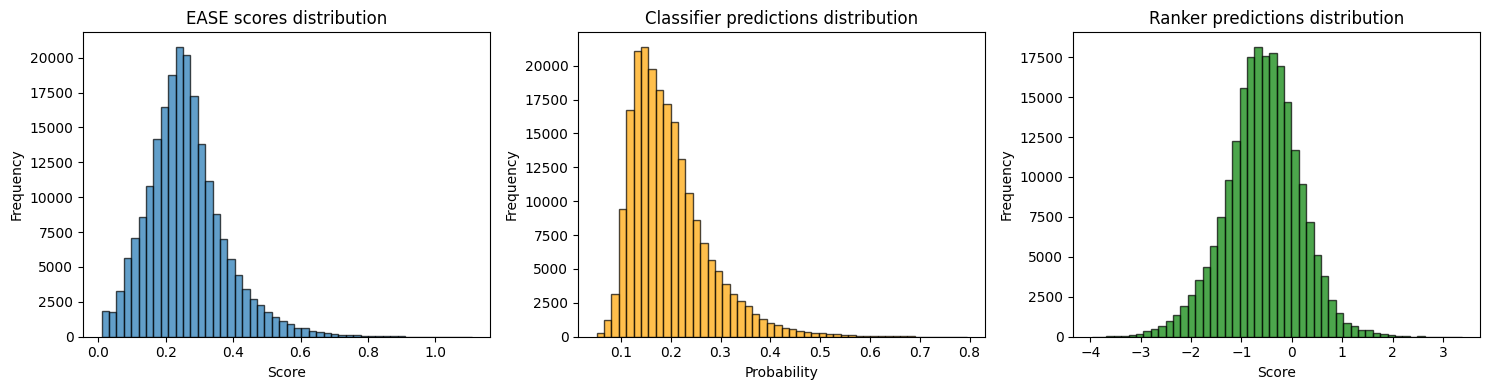


Статистика предсказаний для label=1 (релевантных айтемов):

EASE score:           0.2824 (mean)
Classifier prob:      0.2348 (mean)
Ranker score:         -0.3325 (mean)

Статистика предсказаний для label=0 (нерелевантных айтемов):

EASE score:           0.2564 (mean)
Classifier prob:      0.1916 (mean)
Ranker score:         -0.6156 (mean)

✅ Хороший знак: если для label=1 средние скоры выше, чем для label=0


In [46]:
# Диагностика: сравним распределения предсказаний
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# EASE scores
axes[0].hist(test_bdf['score'], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('EASE scores distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')

# Classifier predictions
axes[1].hist(test_bdf['boosting_preds'], bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title('Classifier predictions distribution')
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Frequency')

# Ranker predictions
axes[2].hist(test_bdf['ranker_preds'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title('Ranker predictions distribution')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Статистика
print("\nСтатистика предсказаний для label=1 (релевантных айтемов):\n")
print(f"EASE score:           {test_bdf[test_bdf.label==1]['score'].mean():.4f} (mean)")
print(f"Classifier prob:      {test_bdf[test_bdf.label==1]['boosting_preds'].mean():.4f} (mean)")
print(f"Ranker score:         {test_bdf[test_bdf.label==1]['ranker_preds'].mean():.4f} (mean)")

print("\nСтатистика предсказаний для label=0 (нерелевантных айтемов):\n")
print(f"EASE score:           {test_bdf[test_bdf.label==0]['score'].mean():.4f} (mean)")
print(f"Classifier prob:      {test_bdf[test_bdf.label==0]['boosting_preds'].mean():.4f} (mean)")
print(f"Ranker score:         {test_bdf[test_bdf.label==0]['ranker_preds'].mean():.4f} (mean)")

print("\n✅ Хороший знак: если для label=1 средние скоры выше, чем для label=0")

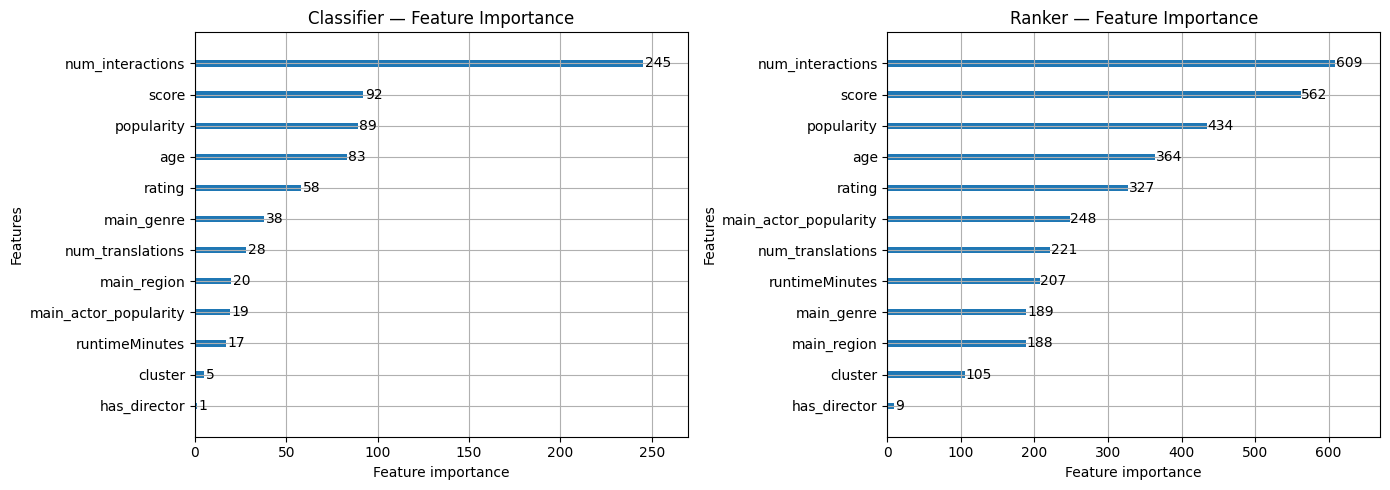

              feature  classifier  ranker
     num_interactions         245     609
                score          92     562
           popularity          89     434
                  age          83     364
               rating          58     327
main_actor_popularity          19     248
     num_translations          28     221
       runtimeMinutes          17     207
           main_genre          38     189
          main_region          20     188
              cluster           5     105
         has_director           1       9
     is_multiregional           0       0


In [47]:
from lightgbm import plot_importance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_importance(clf, ax=axes[0], title='Classifier — Feature Importance')
plot_importance(ranker, ax=axes[1], title='Ranker — Feature Importance')

plt.tight_layout()
plt.show()

# Числовые значения для удобства
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'classifier': clf.feature_importances_,
    'ranker': ranker.feature_importances_
}).sort_values('ranker', ascending=False)

print(importance_df.to_string(index=False))

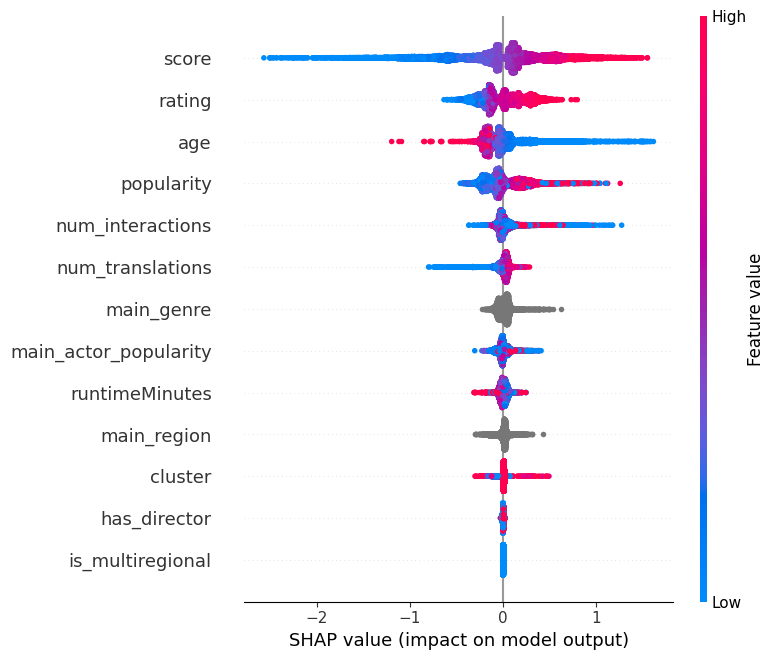

In [48]:
import shap
explainer = shap.TreeExplainer(ranker)
shap_values = explainer.shap_values(test_bdf[FEATURES][:10000])
shap.summary_plot(shap_values, test_bdf[FEATURES][:10000])

Если брать просто актера (аналогично парсить только первое имя из списка) - то это будет сильным якорем для модели, и она перестает обучаться на других признаках. LightGBM (и другие модели) может использовать его как "идентификатор фильма", фактически запоминая конкретные фильмы из трейна, а не обучаясь обобщенным паттернам, что означает утечку данных => Выход: сделать числовую популярность (встречаемость) - main_actor_popularity.
Важность признаков с первым актером:
```
feature  classifier  ranker
      main_actor         253    1199
           score          80     614
num_interactions         193     591
      popularity          62     282
             age          43     197
          rating          32     167
num_translations          14     130
  runtimeMinutes           4      98
         cluster           4      73
      main_genre           7      63
     main_region           8      52
    has_director           0       3
is_multiregional           0       0



### Убираем бесполезные признаки и переобучаем:

In [49]:
# Убираем признаки с нулевой или почти нулевой важностью
FEATURES_V2 = [
    'score',
    'popularity', 
    'age',
    'rating',
    'runtimeMinutes',
    'num_translations',
    'cluster',
    'has_director',
    'num_interactions',
    'main_genre',
    'main_region',
    'main_actor_popularity',
]

# Переобучаем классификатор
clf_v2 = LGBMClassifier(
    max_depth=3, n_estimators=100, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
clf_v2.fit(X=train_balanced[FEATURES_V2], y=train_balanced['label'])
test_bdf['clf_v2_preds'] = clf_v2.predict_proba(test_bdf[FEATURES_V2])[:, 1]

# Переобучаем ранкер
ranker_v2 = LGBMRanker(
    objective='lambdarank', n_estimators=500,
    max_depth=3, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
ranker_v2.fit(
    X=train_ranker[FEATURES_V2],
    y=train_ranker['label'],
    group=train_groups,
    eval_set=[(test_ranker[FEATURES_V2], test_ranker['label'])],
    eval_group=[test_groups],
    callbacks=[lgb.log_evaluation(100)]
)
test_bdf['ranker_v2_preds'] = ranker_v2.predict(test_bdf[FEATURES_V2])

print("\nСравнение v1 vs v2:")
print("=" * 60)
for label, col in [('Classifier v1', 'boosting_preds'), 
                    ('Classifier v2', 'clf_v2_preds'),
                    ('Ranker v1    ', 'ranker_preds'),
                    ('Ranker v2    ', 'ranker_v2_preds')]:
    ndcg, prec, rec = evaluate(test_bdf, col, k_ndcg=10, k_prec=15, k_rec=50)
    print(f"{label}: NDCG@10={ndcg:.4f}, P@15={prec:.4f}, R@50={rec:.4f}")

[100]	valid_0's ndcg@1: 0.469655	valid_0's ndcg@2: 0.451869	valid_0's ndcg@3: 0.443941	valid_0's ndcg@4: 0.438958	valid_0's ndcg@5: 0.434712
[200]	valid_0's ndcg@1: 0.471989	valid_0's ndcg@2: 0.456551	valid_0's ndcg@3: 0.445121	valid_0's ndcg@4: 0.439035	valid_0's ndcg@5: 0.435257
[300]	valid_0's ndcg@1: 0.474323	valid_0's ndcg@2: 0.4588	valid_0's ndcg@3: 0.447349	valid_0's ndcg@4: 0.440911	valid_0's ndcg@5: 0.439052
[400]	valid_0's ndcg@1: 0.475257	valid_0's ndcg@2: 0.460075	valid_0's ndcg@3: 0.447165	valid_0's ndcg@4: 0.441751	valid_0's ndcg@5: 0.439317
[500]	valid_0's ndcg@1: 0.481326	valid_0's ndcg@2: 0.46296	valid_0's ndcg@3: 0.44841	valid_0's ndcg@4: 0.444363	valid_0's ndcg@5: 0.441325

Сравнение v1 vs v2:
Classifier v1: NDCG@10=0.5756, P@15=0.2623, R@50=0.6917
Classifier v2: NDCG@10=0.5756, P@15=0.2623, R@50=0.6917
Ranker v1    : NDCG@10=0.5909, P@15=0.2653, R@50=0.7058
Ranker v2    : NDCG@10=0.5909, P@15=0.2653, R@50=0.7058


# EASE+LightGBM+BERT4Rec

In [50]:
# ПОЛУЧАЕМ СКОРЫ BERT4Rec ДЛЯ ВСЕХ ЮЗЕРОВ
def get_bert4rec_scores(model, joined, item2idx, idx2item, device, batch_size=256):
    """
    Возвращает dict: userId -> dict{movieId -> score}
    """
    model.eval()
    dataset   = BERT4RecDataset(joined, item2idx, max_len=100, phase='test')
    loader    = DataLoader(dataset, batch_size=batch_size,
                           shuffle=False, collate_fn=collate_fn_test)

    user_scores = {}  # userId -> {movieId: score}
    user_ids    = joined["userId"].tolist()
    ptr         = 0   # указатель на текущего юзера в joined

    with torch.no_grad():
        for batch in tqdm(loader, desc="Getting BERT4Rec scores"):
            targets_list = batch.pop("targets")
            batch = {k: v.to(device) for k, v in batch.items()}

            # scores: [B, n_items]
            scores = model.full_sort_predict(batch).cpu().numpy()
            B = scores.shape[0]

            for i in range(B):
                orig_uid = user_ids[ptr]
                ptr += 1

                # топ-200 items достаточно — остальные в LGB не попадут
                top_idx   = np.argsort(scores[i])[::-1][:200]
                top_scores = scores[i][top_idx]

                user_scores[orig_uid] = {
                    idx2item[enc_idx]: float(sc)
                    for enc_idx, sc in zip(top_idx, top_scores)
                    if enc_idx in idx2item
                }

    return user_scores

In [51]:
bert4rec_scores = get_bert4rec_scores(
    model, joined, item2idx, idx2item, DEVICE
)

Getting BERT4Rec scores: 100%|██████████| 34/34 [00:13<00:00,  2.47it/s]


In [52]:
# ДОБАВЛЯЕМ СКОР КАК ФИЧУ В bdf
def lookup_bert_score(row):
    user_dict = bert4rec_scores.get(row["userId"], {})
    return user_dict.get(row["movieId"], 0.0)

bdf["bert4rec_score"] = bdf.apply(lookup_bert_score, axis=1)
print(f"Ненулевых bert4rec_score: {(bdf['bert4rec_score'] != 0).sum()}")

Ненулевых bert4rec_score: 315801


In [53]:
FEATURES_V2 = FEATURES_V2 + ["bert4rec_score"]

# Пересобираем train_balanced и test_bdf с новой фичей
# (всё то же самое что раньше, просто добавляем колонку)
for col in ["main_genre", "main_region"]:
    bdf[col] = bdf[col].astype("category")

train_bdf_v2 = bdf.iloc[train_idx].copy()
test_bdf_v2  = bdf.iloc[test_idx].copy()

pos = train_bdf_v2[train_bdf_v2["label"] == 1].copy()
neg = train_bdf_v2[train_bdf_v2["label"] == 0].sample(
    pos.shape[0] * 4, random_state=42
)
train_balanced_v2 = pd.concat([pos, neg]).sample(frac=1, random_state=42)

clf_v2 = LGBMClassifier(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
clf_v2.fit(
    X=train_balanced_v2[FEATURES_V2],
    y=train_balanced_v2["label"]
)

test_bdf_v2["boosting_preds_v2"] = clf_v2.predict_proba(
    test_bdf_v2[FEATURES_V2]
)[:, 1]

ndcg, prec, rec = evaluate(
    test_bdf_v2, score_col="boosting_preds_v2",
    k_ndcg=10, k_prec=15, k_rec=50
)
print(f"\n=== EASE + LGB + BERT4Rec score ===")
print(f"NDCG@10   : {ndcg:.4f}")
print(f"Prec@15   : {prec:.4f}")
print(f"Recall@50 : {rec:.4f}")


=== EASE + LGB + BERT4Rec score ===
NDCG@10   : 0.5802
Prec@15   : 0.2621
Recall@50 : 0.6914
